# Default and transition analysis

Default is the first 90+ DPD, REO or configured credit-related terminal event. The state matrix is a lifetime-PD benchmark.

In [1]:
from pathlib import Path
import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
DB = ROOT / "database" / "ifrs9_ecl.sqlite3"
CFG = yaml.safe_load((ROOT / "config" / "project.yaml").read_text())

def query(sql):
    with sqlite3.connect(DB) as connection:
        return pd.read_sql_query(sql, connection)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
transitions = query("select * from transition_matrix"); transitions

,from_state,to_state,transition_probability
0,Current/<30,Current/<30,0.9958
1,30-59,Current/<30,0.4500
2,60-89,Current/<30,0.1741
3,Default/90+,Current/<30,0.0984
4,Current/<30,30-59,0.0042
5,30-59,30-59,0.3636
6,60-89,30-59,0.1204
7,Default/90+,30-59,0.0125
8,Current/<30,60-89,0.0000
9,30-59,60-89,0.1848


In [3]:
matrix = transitions.pivot(index='from_state', columns='to_state', values='transition_probability').fillna(0)
matrix

to_state,30-59,60-89,Current/<30,Default/90+
from_state,,,,
30-59,0.3636,0.1848,0.4500,0.0017
60-89,0.1204,0.2447,0.1741,0.4609
Current/<30,0.0042,0.0000,0.9958,0.0000
Default/90+,0.0125,0.0168,0.0984,0.8722


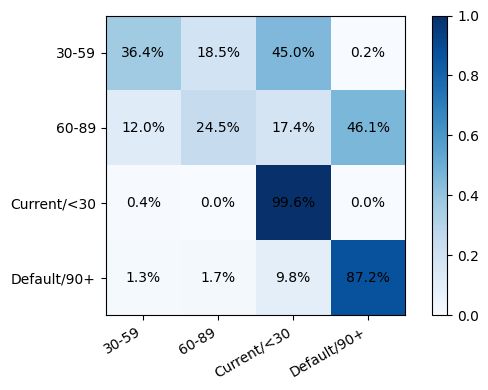

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
image = ax.imshow(matrix.values, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=30, ha='right')
ax.set_yticks(range(len(matrix.index)), matrix.index)
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        ax.text(j, i, f'{matrix.iloc[i,j]:.1%}', ha='center', va='center')
plt.colorbar(image, ax=ax); plt.tight_layout()

In [5]:
query("select completed_workout, count(*) defaults, avg(workout_lgd) average_lgd from default_workout_recovery group by completed_workout")

,completed_workout,defaults,average_lgd
0,0,283,0.0628
1,1,325,0.0898


A cure is a move from a delinquent state to a lower-risk state in the following observed month. Only consecutive monthly records enter the matrix.

Output: consistent default dates, default events, cure rates and roll rates.